Number of misgrouped points: 93


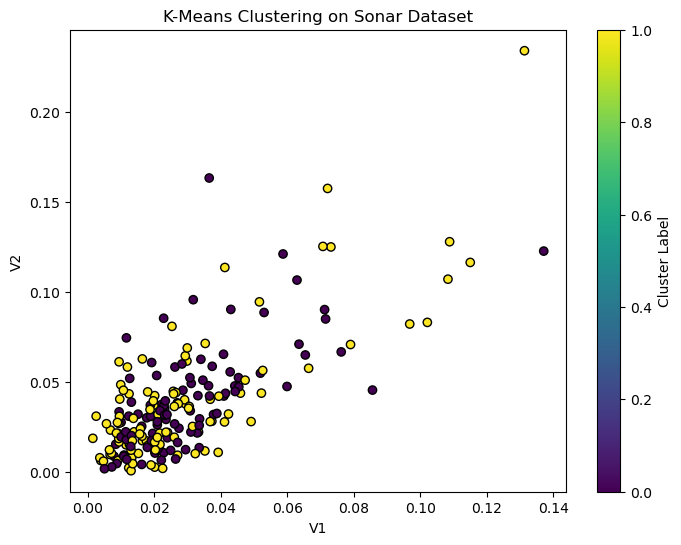

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load data
data = pd.read_csv("data/sonar.csv")
X = data.drop('Class', axis=1)
y = data['Class']

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=0, n_init=100, algorithm='lloyd')
kmeans.fit(X)
predicted_labels = kmeans.labels_

# Calculate misgrouped points (accounting for label inversion)
a = np.sum(predicted_labels == y)
b = np.sum(1 - predicted_labels == y)
correct_labels = max(a, b)
miss_grouped = len(y) - correct_labels
print(f"Number of misgrouped points: {miss_grouped}")

# Visualization (using first two features)
feature1 = X.columns[0]
feature2 = X.columns[1]
plt.figure(figsize=(8, 6))
plt.scatter(X[feature1], X[feature2], c=predicted_labels, cmap='viridis', edgecolor='k')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('K-Means Clustering on Sonar Dataset')
plt.colorbar(label='Cluster Label')
plt.show()